# A ladder down, then a leap back up 🪜
### The ladder bottom: a five-candle bounce story that's almost — but not quite — provable

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_downtrend_base_rate%3F: Mixed](https://img.shields.io/badge/Beats_a_downtrend_base_rate%3F-Mixed-8b949e?style=flat-square)

Picture a stock in a slide: four straight red days, each closing lower than the last, each one a rung on a ladder heading down. Then, on the fifth day, it snaps back — a strong green candle that breaks the fall. Candlestick lore calls this the **ladder bottom**, and says it marks the exact moment sellers run out of gas and buyers take over.

It's a great story. We tested it on 61 big US stocks over 25 years — every single time the shape appeared, both the common reading and the stricter, more literal one — and the answer turned out to be one of the more interesting kinds of "no" this desk has produced: **not busted, not confirmed, just short.**

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Two cuts: a **loose** one (four falling candles, then a bullish break) and a **strict** one (adds the textbook "warning wick" and a true gap-up reversal). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ladder_bottom import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real cache present:", HAVE_REAL, "| basket size:", len(data.BASKET))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_names': 61, 'years': 25.0, 'total_bars': 383080, 'asof': '2026-06-30', 'fp_spy': '85f86a841de4', 'fp_panel': '9693c3ea7807', 'n_loose': 2543, 'n_strict': 81, 'bonferroni_crit': 2.5, 'loose': {1: (2543, -3.8, 47.2, 2.7, -6.5, -1.87, 0.981, -13.8), 5: (2543, 46.6, 56.2, 27.5, 19.1, 2.24, 0.009, 36.6), 10: (2543, 54.5, 56.2, 55.5, -1.0, -0.08, 0.528, 44.5), 20: (2543, 154.7, 59.9, 120.0, 34.8, 2.12, 0.011, 144.7)}, 'strict': {1: (81, -13.2, 43.2, -15.9, -0.71, 0.805, -23.2), 5: (81, 107.8, 55.6, 80.3, 1.52, 0.045, 97.8), 10: (81, 129.5, 53.1, 74.0, 1.11, 0.109, 119.5), 20: (81, 339.8, 64.2, 219.8, 2.3, 0.006, 329.8)}, 'strict_events': [('NKE', '2026-03-10', '2026-03-16', -2028.9), ('LMT', '2003-01-16', '2003-01-23', -1233.2), ('BA', '2009-02-26', '2009-03-04', 2128.7), ('KMB', '2020-03-18', '2020-03-24', 2143.9), ('MS', '2002-10-02', '2002-10-08', 3973.3)], 'syn_null_mean': 0.02, 'syn_null_sd': 0.97, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_edge_002_t': 2.85, 'syn_edge_002_delta': 33.8, 'syn_edge_004_t': 4.02, 'syn_edge_004_delta': 49.2}


real cache present: True | basket size: 61


## The answer first

| Question | Answer |
|---|---|
| How often does the *common* reading fire? | **A lot — 2,543 times** across 61 stocks over 25 years. But it does nothing reliable: the 1-day reaction is *negative*, the 10-day reaction is flat, and only two of four time horizons even nominally beat the desk's significance bar (and neither survives being tested fairly against three others). |
| How often does the *real*, textbook version fire? | Only **81** times — about once every **19 stock-years**. Genuinely rare, exactly as the old books say. |
| Does the rare version do better? | **Yes, tantalizingly.** It points the right way three horizons out of four, with a 20-day return of **+3.4%** net of costs — but its best number falls just short of the bar the desk sets for calling something real. |
| So is it real? | **We can't say yes, and we can't say no either.** That's the honest finding — and it happens less often here than you'd think. |

> Some of the best-looking wins happened right at the 2002, 2009 and 2020 market bottoms — which is either a beautiful confirmation, or a reminder that when the whole market bounces, every pattern near the bottom looks like a genius call.

## 1 · The claim

> *"A downtrend that produces four straight falling candles — a visible 'ladder' stepping down — followed by a fifth candle that reverses and closes higher, marks the exact bottom. The fourth candle often shows a long upper shadow: a hint that buyers are already starting to push back before the reversal actually prints."* — the ladder bottom, per Steve Nison's *Japanese Candlestick Charting Techniques*.

It's a specific, mechanical-sounding claim — which makes it a great one to actually test instead of just eyeball on a chart.

## 2 · So what?

If real, this is a chartist's dream: a mechanical, countable five-candle shape that tells you *exactly* when a downtrend is over, before the news does. That would beat just "buying the dip" whenever a stock has fallen for a while — the pattern would have to add real, specific information on top of ordinary mean-reversion. So the honest test isn't "did the stock bounce after four red days" (stocks often do) — it's "did the *specific* ladder shape bounce *more* than an ordinary bar already sitting in the same kind of downtrend."

## 3 · How would we even know?

- **The basket.** SPY + **60** long-listed US large-caps across every major sector, **25 years** of daily bars each (383,080 bars total).
- **Two honest cuts.** The **loose** ladder (four falling candles, strictly declining closes, in a genuine downtrend, then a bullish break) and the **strict** one (adds small selling-conviction shadows on the first three rungs, a longer "warning" wick on the fourth, and a true gap-up on the fifth) — reported side by side.
- **The trade.** Buy at the next open (one lag — you can't trade the close you just saw), hold 1/5/10/20 days.
- **The honest bar.** Compare against the same buy on **any other bar already sitting in a matching downtrend** — not just "any day" — and correct for testing four time horizons at once (a **Bonferroni** correction).

## 4 · The teardown — let's actually look

**First: how rare is the *real* ladder bottom, really?**

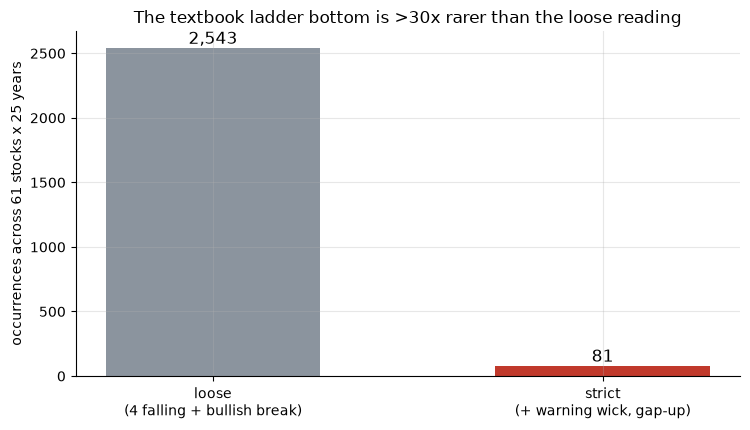

loose: 2,543  strict: 81  (out of 383,080 trading days pooled)


In [2]:
labels = ['loose\n(4 falling + bullish break)', 'strict\n(+ warning wick, gap-up)']
counts = [R['n_loose'], R['n_strict']]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(labels, counts, color=[GREY, RED], width=.55)
for i, v in enumerate(counts): ax.annotate(f'{v:,}', (i, v), ha='center', va='bottom', fontsize=12)
ax.set_ylabel(f'occurrences across {R["n_names"]} stocks x {R["years"]:.0f} years')
ax.set_title('The textbook ladder bottom is >30x rarer than the loose reading')
plt.tight_layout(); plt.show()
print(f"loose: {R['n_loose']:,}  strict: {R['n_strict']}  (out of {R['total_bars']:,} trading days pooled)")

**2,543** vs **81**. Demanding the actual warning-wick-plus-gap shape the books describe collapses the count by more than 30x — the pattern's own reputation for rarity turns out to be earned.

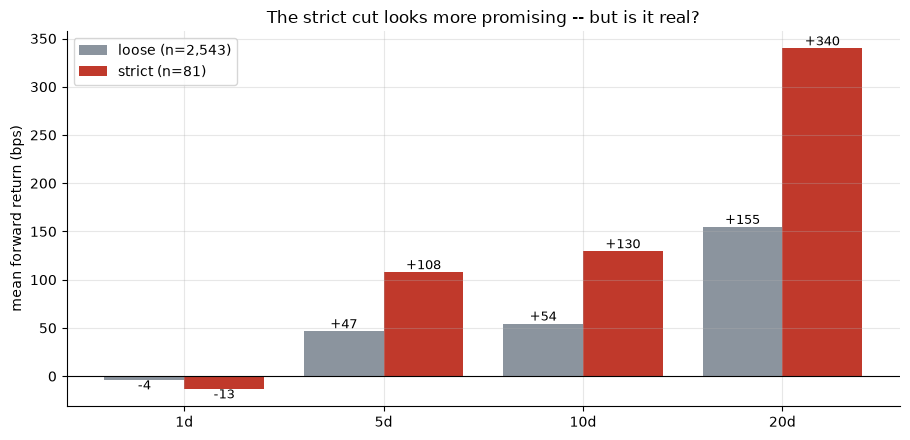

loose: [-3.8, 46.6, 54.5, 154.7]
strict: [-13.2, 107.8, 129.5, 339.8]


In [3]:
hs = [1, 5, 10, 20]
loose = [R['loose'][h][1] for h in hs]
strict = [R['strict'][h][1] for h in hs]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
x = np.arange(len(hs))
ax.bar(x-.2, loose, .4, color=GREY, label=f'loose (n={R["n_loose"]:,})')
ax.bar(x+.2, strict, .4, color=RED, label=f'strict (n={R["n_strict"]})')
for i,(a,b) in enumerate(zip(loose,strict)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=9)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='top' if b<0 else 'bottom',fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The strict cut looks more promising -- but is it real?')
ax.legend(); plt.tight_layout(); plt.show()
print('loose:', loose); print('strict:', strict)

The loose reading is a mess: negative on day 1, positive by day 5, roughly flat by day 10, positive again by day 20. That kind of sign-flipping across horizons is exactly what noise looks like, not a persistent signal.

The strict reading tells a cleaner story — down on day 1, then a steadily building positive return, reaching **+340 bps (+3.4%)** by day 20. That's the interesting number in this whole study. But is it bigger than what an ordinary downtrend bar would give you anyway?

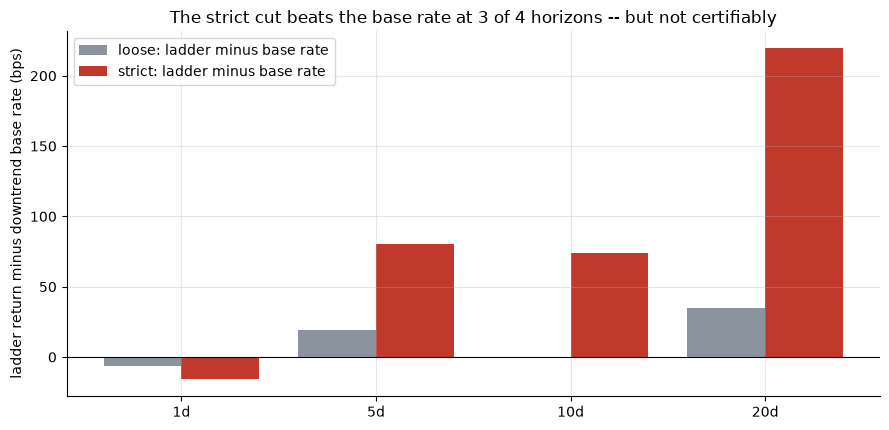

loose deltas: [-6.5, 19.1, -1.0, 34.8]
strict deltas: [-15.9, 80.3, 74.0, 219.8]


In [4]:
hs = [1, 5, 10, 20]
deltas_loose = [R['loose'][h][4] for h in hs]
deltas_strict = [R['strict'][h][3] for h in hs]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
x = np.arange(len(hs))
ax.bar(x-.2, deltas_loose, .4, color=GREY, label='loose: ladder minus base rate')
ax.bar(x+.2, deltas_strict, .4, color=RED, label='strict: ladder minus base rate')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('ladder return minus downtrend base rate (bps)')
ax.set_title('The strict cut beats the base rate at 3 of 4 horizons -- but not certifiably')
ax.legend(); plt.tight_layout(); plt.show()
print('loose deltas:', deltas_loose); print('strict deltas:', deltas_strict)

The strict cut *does* beat the base rate at 5, 10 and 20 days. The 20-day gap (**+220 bps**) is the biggest and most consistent number in the study, with a statistical score of **t = 2.30** — close to (but short of) the bar the desk requires to call an effect real once you account for testing four time horizons at once. The quants notebook has the full Bonferroni arithmetic; the honest headline is: **suggestive, not certified.**

**One more thing worth seeing** — where the biggest wins and losses actually happened:

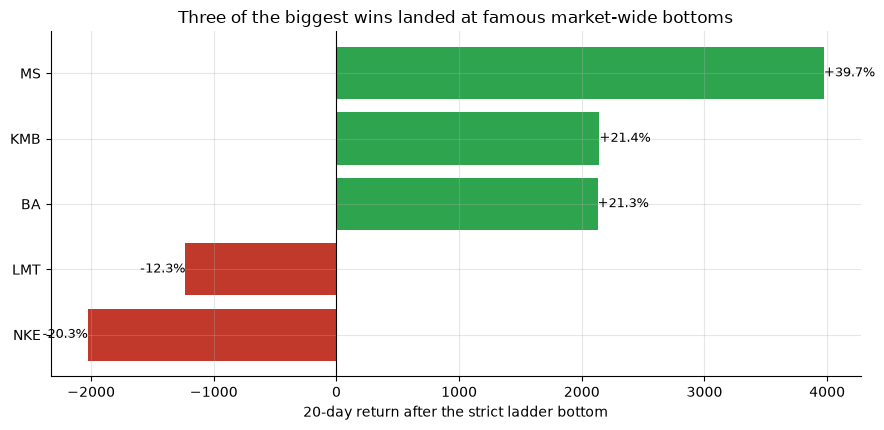

NKE: 2026-03-10->2026-03-16  -20.3%
LMT: 2003-01-16->2003-01-23  -12.3%
BA: 2009-02-26->2009-03-04  +21.3%
KMB: 2020-03-18->2020-03-24  +21.4%
MS: 2002-10-02->2002-10-08  +39.7%


In [5]:
names = [e[0] for e in R['strict_events']]
vals = [e[3] for e in R['strict_events']]
cols = [RED if v < 0 else GREEN for v in vals]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.barh(names, vals, color=cols)
ax.axvline(0, c='k', lw=.8)
for i, v in enumerate(vals): ax.annotate(f'{v/100:+.1f}%', (v, i), va='center',
    ha='left' if v>0 else 'right', fontsize=9)
ax.set_xlabel('20-day return after the strict ladder bottom')
ax.set_title('Three of the biggest wins landed at famous market-wide bottoms')
plt.tight_layout(); plt.show()
for tkr, d0, d1, r20 in R['strict_events']: print(f'{tkr}: {d0}->{d1}  {r20/100:+.1f}%')

MS (October 2002), BA (February–March 2009) and KMB (March 2020) all fired their ladder bottom right at, or days before, a **famous, market-wide** bottom — the dot-com low, the GFC low, and the COVID crash low. That's either the pattern doing exactly what it claims, or a reminder that near a real market bottom, *almost every* stock chart draws something that looks like a bullish setup — and with only 81 events, we can't fully tell those two stories apart.

## 5 · The verdict

- **Signal — None.** Neither cut clears the desk's significance bar once you account for testing four horizons at once. The common reading contradicts itself across horizons; the rare, textbook-faithful reading comes closer (and points the right way more often) but still falls short.
- **Tradability — Mirage.** The textbook version fires about once every 19 stock-years — nowhere near often enough to build a strategy on, whatever the statistics say.
- **"Beats a downtrend base rate?" — Mixed.** The strict cut is economically interesting and directionally right most of the time — genuinely the study's most promising thread — but it is neither confirmed nor busted on the sample size real markets offer.

## 6 · Going further 🚪

- **"Almost significant" is its own honest answer.** Most of this desk's candlestick teardowns land firmly on None; this one lands on a genuinely close miss — worth naming precisely instead of rounding up to Real or down to Busted.
- **What would move the needle:** more names, more decades, or — the more promising route — testing whether the pattern's edge concentrates specifically around genuine market-wide drawdown bottoms (which this basket's five best/worst events hint at) rather than firing evenly across all conditions.
- **Sibling studies:** [455-three-methods](../../455-three-methods/) (a different 5-candle shape, a continuation not a reversal), [408-three-black-crows](../../408-three-black-crows/) (the same four falling candles, read bearish instead), [186-morning-star](../../186-morning-star/) (a 3-candle bullish reversal) and [685-tri-star-doji](../../685-tri-star-doji/) (this study's strict/loose discipline, on three dojis instead).

*Think the strict cut is onto something real? Show it survives on a broader universe or a longer tape with the Bonferroni bar still in place — then we'll talk.*